# TFG


- [Simulación mediante EME](FINAL_PROJECT_DEEP_SIN.ipynb)
- [Simulación de la respuesta del circuito en Sax](SAX_SIN.ipynb)
- [Layout](LAYOUT_SIN.ipynb)


En este repositorio se presenta el trabajo final de la asignatura de diseño. El trabajo consta de tres partes principales: simulación mediante EME, simulación de la respuesta del circuito en Sax y layout del circuito. Mediante los enlaces de la celda superior es posible acceder a los notebooks correspomdientes a cada sección. 

# Índice: simulaciones mediante EME


- [Análisis de cross section](#analisis-cross-section)
  - [MMI](#mmi)
    - [Estudio de malla](#estudio-malla)
    - [Obtención de $L_{\pi}$](#lpi)
  - [Guías](#guias)
    - [Waveguide width dependence](#waveguide-width-dependence)
    - [Obtención de índice de grupo](#indice-grupo)
    - [Bend losses analisis](#bend-losses)
- [Optimización](#optimizacion)
  - [MMI 95:05](#mmi-95-05)
  - [MMI 33:33:33](#mmi-33-33-33)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt
import gplugins.tidy3d.materials as mat
from gplugins import plot
from gplugins.common.config import PATH

from upvfab_design_tools import MMI_EME, DC_EME

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)


<a id="analisis-cross-section"></a>
## Análisis de cross section

<a id="mmi"></a>
### MMI

<a id="estudio-malla"></a>
#### Estudio de malla

Tras la simulación de la malla se decide; grid_resolution = 40 y max_grid_scaliing = 1.45 .

2026-05-18 11:04:58.507 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24c33edd2fbe1881.npz.
2026-05-18 11:04:58.516 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_39b273c5448a402f.npz.
2026-05-18 11:04:58.522 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2c40f9ab444edd2b.npz.
2026-05-18 11:04:58.525 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1f4d5bd178843423.npz.
2026-05-18 11:04:58.532 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c4b58fd0c9d996c5.npz.
2026-05-18 11:04:58.536 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f5ce037f102dc7b6.npz.
2026-05-18 11:04:58.540 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b8b190484d25a0db.npz.


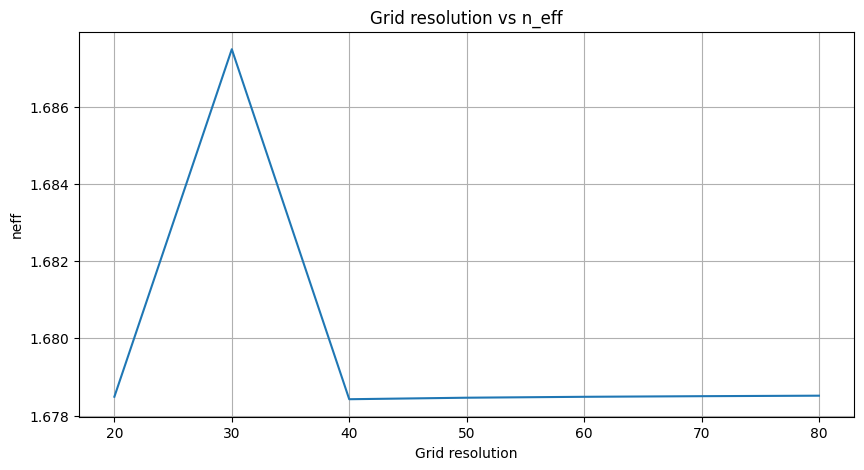

In [6]:
mmi_body_w = 10
lambda_c = 1.55
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []

for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.2, # Parameters of the grid
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"Grid resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

2026-05-18 11:05:03.626 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2c40f9ab444edd2b.npz.
2026-05-18 11:05:03.631 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_22a3ad30c6ca35bf.npz.
2026-05-18 11:05:03.636 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7329da91ae8f46b5.npz.
2026-05-18 11:05:03.642 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24acf4d4c2c0ca94.npz.
2026-05-18 11:05:03.646 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_13194a9bce33ff22.npz.
2026-05-18 11:05:03.648 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_162c8f788cee3692.npz.
2026-05-18 11:05:03.650 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_31d979412394fa4b.npz.


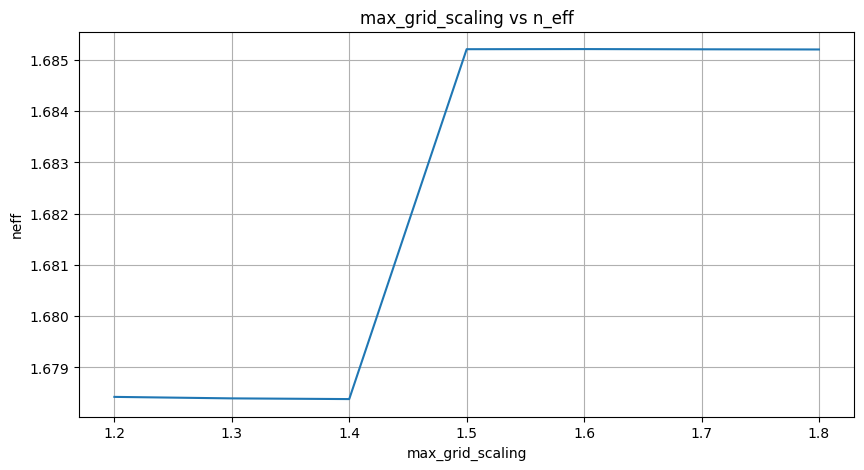

In [7]:
n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []


for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid
        grid_resolution=40, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-05-18 11:07:51.881 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_108e6feb9bd5cb8b.npz.
Fracción TE: [0.99998801 0.99995117]


array([1.67835755+7.78501263e-05j, 1.67331589+7.82577262e-05j])

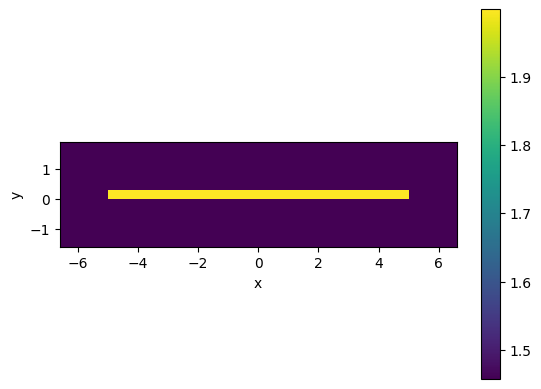

In [8]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.45, # Parameters of the grid
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

<a id="lpi"></a>
#### Obtención de $L_{\pi}$

In [9]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

153.71944910050703


<a id="guias"></a>
### Guías  CAMBIAR WIDTH A 1!!!! 


## Waveguide width dependence

Realmente queremos que haya muy buen confinamiento porque tendremos muchas pérdidas en el brazo largo. Elegimos un width de 1.  (tmb porque solemos cogerlo en las simulaciones)

  0%|          | 0/13 [00:00<?, ?it/s]

2026-06-09 20:23:14.371 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_91555884b1d5da38.npz.
2026-06-09 20:23:14.402 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bc28f221a791dd0e.npz.
2026-06-09 20:23:14.405 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_203585dc557d3766.npz.
2026-06-09 20:23:14.409 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_01f69bbe128ede1f.npz.
2026-06-09 20:23:14.413 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c2d44042827f342b.npz.
2026-06-09 20:23:14.417 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_16185d8543a964fc.npz.
2026-06-09 20:23:14.420 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f0828f6f78af6364.npz.
2026-06-09 20:23:14.425 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24b1327d73545743.npz.


  0%|          | 0/13 [00:00<?, ?it/s]

2026-06-09 20:23:14.456 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_91555884b1d5da38.npz.
2026-06-09 20:23:14.460 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bc28f221a791dd0e.npz.
2026-06-09 20:23:14.464 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_203585dc557d3766.npz.
2026-06-09 20:23:14.468 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_01f69bbe128ede1f.npz.
2026-06-09 20:23:14.471 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c2d44042827f342b.npz.
2026-06-09 20:23:14.474 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_16185d8543a964fc.npz.
2026-06-09 20:23:14.476 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f0828f6f78af6364.npz.
2026-06-09 20:23:14.479 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24b1327d73545743.npz.


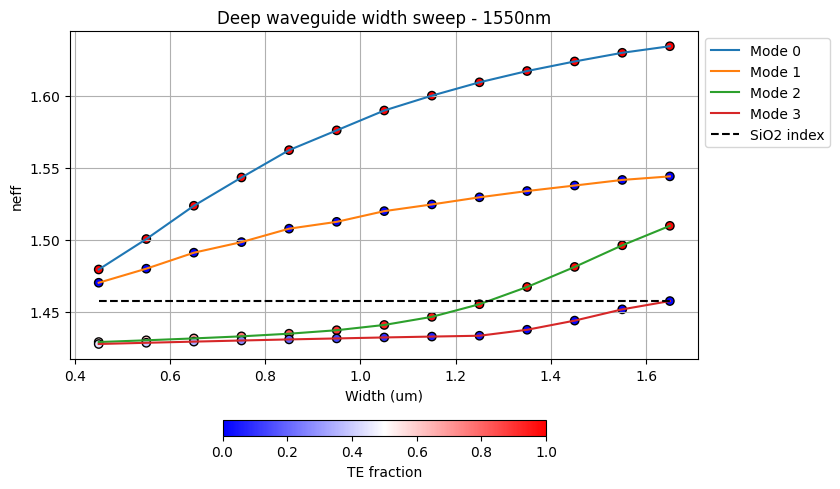

In [2]:
wavelength = 1.55 # Student code here



deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.45,1.65,13) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

Para la simulación de las guías también se ha hecho un estudio de malla previo tras el que se ha decidido usar: grif_resolution = 40 y max_grid_sacling = 1.45 

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

20:23:52 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-06-09 20:23:52.017 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ab5fee3ed0e09531.npz.


array(1.58340824)

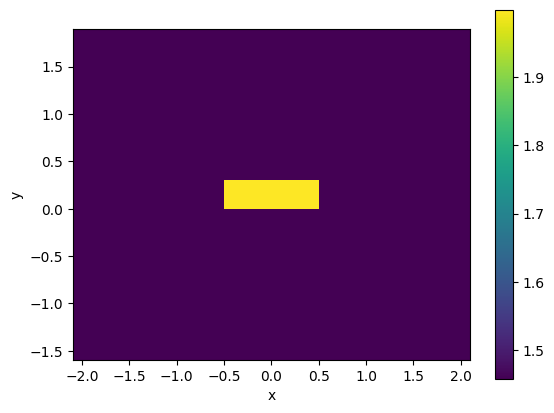

In [3]:
lambda_c = 1.55

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.45, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()
deep_waveguide.n_eff.real

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:24:17.344 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_7260bacce879b687.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:24:18.335 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_fa3cce4c893ba42c.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

...

2026-06-09 20:24:27.366 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_f487e4680502d131.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:24:34.887 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_2c9c4a76a1368008.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:24:43.554 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ed269cd6895e3798.npz.


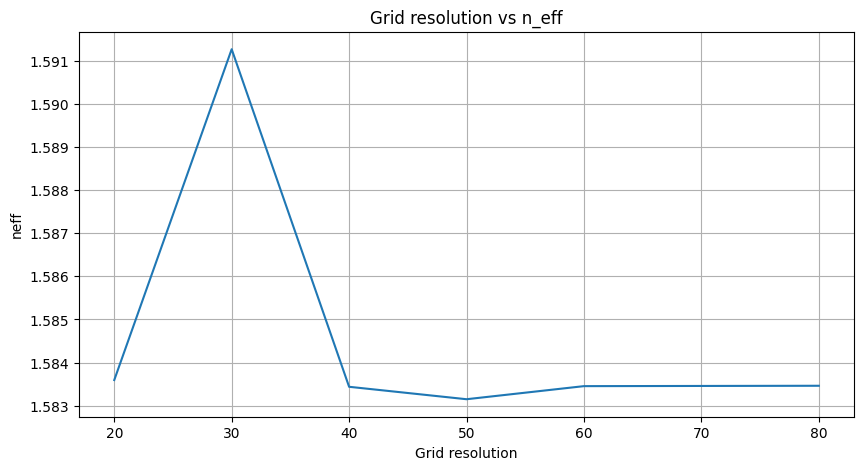

In [5]:
lambda_c = 1.55
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []

for i in range(n_steps): 
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.2, # Parameters of the grid
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"Grid resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

2026-06-09 20:25:46.373 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f7acf35b28f6a7de.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:25:48.782 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_eb21a8e7ea176616.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:25:51.287 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_d6acfd003f324f35.npz.


...

2026-06-09 20:25:54.936 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9e47da7557e8bad1.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:26:00.113 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_a6754fca6431fc6e.npz.


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:26:01.757 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6598a26c17dabff8.npz.


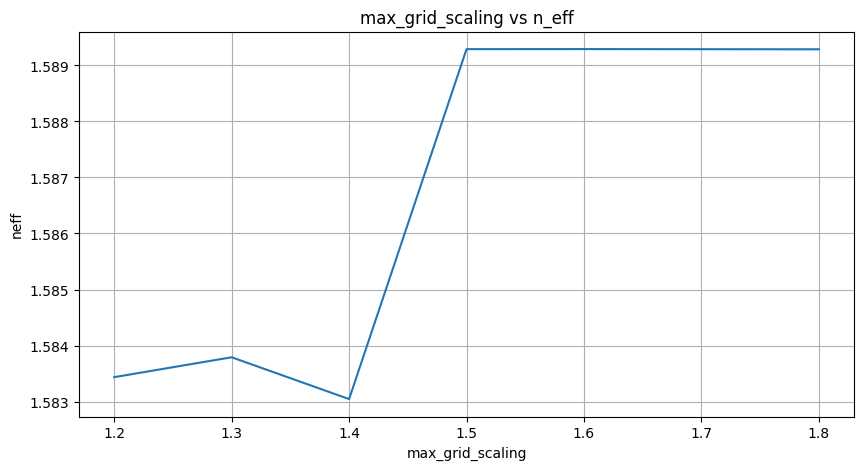

In [6]:
n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []


for i in range(n_steps): 
    deep_waveguide= gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1 ,# MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid
        grid_resolution=40, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

<a id="indice-grupo"></a>
#### Obtención de índice de grupo

In [7]:
wl = np.linspace(1.5,1.6, 200)

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=wl, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.45, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

neff = deep_waveguide.n_eff.real




ng = neff - wl * np.gradient(neff, wl)

print(ng)

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-06-09 20:33:14.640 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ce146001b4e4de11.npz.
[1.94210658 1.94201705 1.94183798 1.94165883 1.94147963 1.94130035
 1.94112102 1.94094162 1.94076216 1.94058263 1.94040304 1.94022339
 1.94004367 1.93986389 1.93968404 1.93950414 1.93932417 1.93914413
 1.93896404 1.93878388 1.93860365 1.93842337 1.93824302 1.93806261
 1.93788214 1.9377016  1.93752101 1.93734035 1.93715963 1.93697884
 1.936798   1.93661709 1.93643612 1.93625509 1.936074   1.93589285
 1.93571164 1.93553036 1.93534903 1.93516763 1.93498617 1.93480465
 1.93462307 1.93444143 1.93425973 1.93407797 1.93389615 1.93371427
 1.93353233 1.93335033 1.93316827 1.93298615 1.93280396 1.93262172
 1.93243943 1.93225707 1.93207465 1.93189217 1.93170963 1.93152704
 1.93134438 1.93116167 1.9309789  1.93079607 1.93061318 1.93043023
 1.93024723 1.93006416 1.92988104 1.92969786 1.92951463 1.92933133
 1.92914798 1.92896457 1.9287811  1.92859758 1.92841399 1.92823036
 1.

In [8]:
print(neff)

[1.59471974 1.59460336 1.59448705 1.59437079 1.59425459 1.59413845
 1.59402238 1.59390636 1.5937904  1.5936745  1.59355866 1.59344289
 1.59332717 1.59321151 1.59309591 1.59298037 1.5928649  1.59274948
 1.59263412 1.59251882 1.59240359 1.59228841 1.59217329 1.59205823
 1.59194323 1.59182829 1.59171342 1.5915986  1.59148384 1.59136914
 1.5912545  1.59113993 1.59102541 1.59091095 1.59079655 1.59068221
 1.59056794 1.59045372 1.59033956 1.59022546 1.59011142 1.58999744
 1.58988353 1.58976967 1.58965587 1.58954213 1.58942845 1.58931484
 1.58920128 1.58908778 1.58897434 1.58886096 1.58874764 1.58863439
 1.58852119 1.58840805 1.58829497 1.58818195 1.58806899 1.5879561
 1.58784326 1.58773048 1.58761776 1.5875051  1.58739251 1.58727997
 1.58716749 1.58705507 1.58694271 1.58683041 1.58671818 1.586606
 1.58649388 1.58638182 1.58626982 1.58615788 1.58604601 1.58593419
 1.58582243 1.58571073 1.58559909 1.58548751 1.58537599 1.58526454
 1.58515314 1.5850418  1.58493052 1.5848193  1.58470814 1.5845970

In [9]:
# índice de grupo a wl=1.55
idx = np.argmin(abs(wl - 1.55))
ng_wl0 = ng[idx]
print(ng_wl0)

1.9241760728907733


In [10]:
# Cálculo de la diferencia de longitud de brazos necesaria para obtener un FSR de 10 pm con los datos simulados.
FSR = 1e-5 #um = 10pm
wl0 = 1.55

AL = (wl0**2)/(ng_wl0*FSR)

print(f'AL = {AL}')

AL = 124858.636059777


## Bend losses

Bend radius with less losses: 75 um/100 um. 

  0%|          | 0/6 [00:00<?, ?it/s]

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

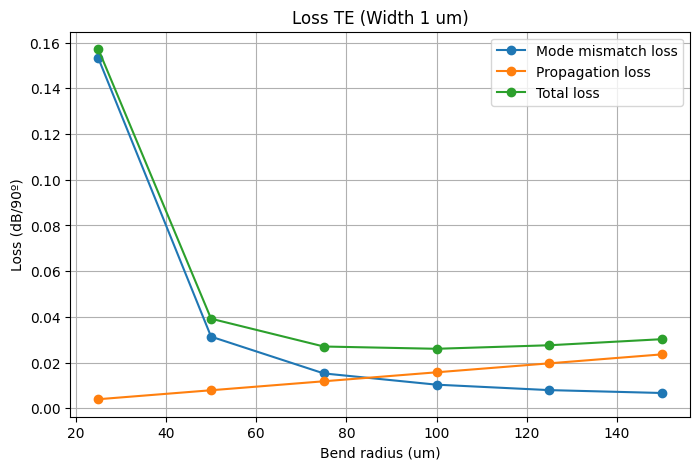

In [12]:
bend_radius = np.linspace(25, 150, 6)
te_wvg = gt.modes.Waveguide(
    wavelength=1550 * nm, 
    core_width=1,       
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.45,
    grid_resolution=40, 
)



mismatch_loss = gt.modes.sweep_bend_mismatch(te_wvg, bend_radius)
mismatch_loss_dB = -10 * np.log10(mismatch_loss) 
dB_cm = 1
length_cm = 0.5 * np.pi * bend_radius * 1e-4
prop_loss_dB = dB_cm * length_cm
total_loss_dB = mismatch_loss_dB + prop_loss_dB

plt.figure(figsize=(8,5))
plt.title("Loss TE (Width 1 um)")
plt.plot(bend_radius, mismatch_loss_dB, "o-", label="Mode mismatch loss")
plt.plot(bend_radius, prop_loss_dB, "o-", label="Propagation loss")
plt.plot(bend_radius, total_loss_dB, "o-", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.legend()
plt.grid(True)
plt.show()

<a id="optimizacion"></a>
## Optimización

En la siguiente sección se ha realizado la optimización de los MMI's con el fin de obtener las relaciones de potencia deseadas  y reducir las pérdidas al máximo. 

<a id="mmi-33-33-33"></a>
### MMI 33:33:33

In [ ]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 10  # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width

m.wg_width=2
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.VERBOSE = True
m.find_all_modes()

# 2) Get the L_pi 
L_pi_eme = m.get_L_pi()

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3009 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.0000
IO wg width 2.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9894
Total OUT power: 0.6444
Excess loss [dB] =  1.9083
------------------------
Power over OUTs:  ['0.0949', '0.2267', '0.3228']
Ratio over OUTs ['0.1472', '0.3518', '0.5010']


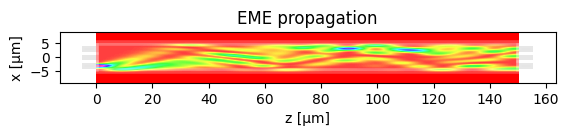

In [48]:
m.dL_MMI = 0
dy = 0
m.n_IN = 3
m.n_OUT = 3

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-3, 0, 3])
m.OUT_WVG_positions =np.array([-3, 0,  3])

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi_eme


# Run propagation
m.propagation()

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3019 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.5000
IO wg width 2.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9957
Total OUT power: 0.9619
Excess loss [dB] =  0.1689
------------------------
Power over OUTs:  ['0.3181', '0.3130', '0.3307']
Ratio over OUTs ['0.3308', '0.3255', '0.3438']


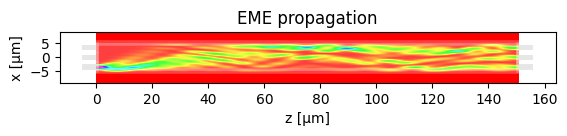

In [74]:

dy = 0.5

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy]) # STUDENT
m.OUT_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy,0, dy]) # STUDENT4


# MMI length (check class slides for type of MMI)
m.dL_MMI = 0.5 #3.5 # STUDENT

# Run propagation
m.propagation()

Parámetros escogidos para el diseño del circuito: parámetros correspondientes a wg_width = 2.8 .

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3019 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.5000
IO wg width 2.4000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0014
Total OUT power: 0.9834
Excess loss [dB] =  0.0725
------------------------
Power over OUTs:  ['0.3272', '0.3193', '0.3370']
Ratio over OUTs ['0.3327', '0.3247', '0.3426']


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 150.4331
MMI length increment 0.5000
IO wg width 2.7000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0011
Total OUT power: 0.9897
Excess loss [dB] =  0.0450
------------------------
Power over OUTs:  ['0.3302', '0.3226', '0.3369']
Ratio over OUTs ['0.3336', '0.3260', '0.3404']


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3019 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.5000
IO wg width 2.8000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0006
Total OUT power: 0.9906
Excess loss [dB] =  0.0411
------------------------
Power over OUTs:  ['0.3305', '0.3237', '0.3364']
Ratio over OUTs ['0.3336', '0.3267', '0.3396']


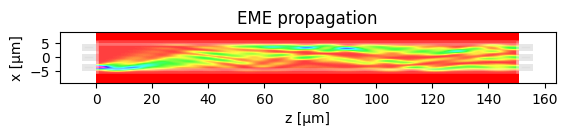

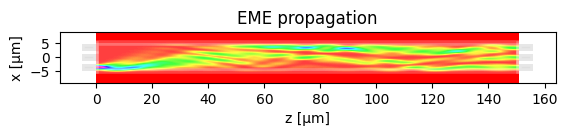

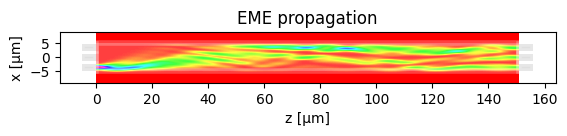

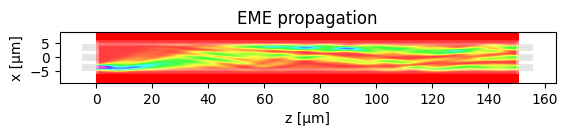

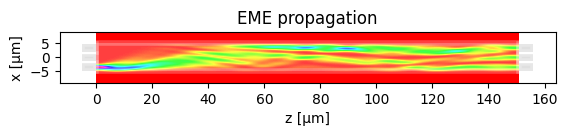

In [2]:
widths = [2.4, 2.5, 2.6, 2.7, 2.8] ############# 2.8 ELEGIDO COMO OPTIMIZADO !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!1
mmi_Width = 10

for dw in widths:
    m = MMI_EME() 
    m.MMI_width = mmi_Width
    m.wg_width=dw
    m.MMI_num_modes = 30
    
    m.find_all_modes()
    L_pi_eme = m.get_L_pi()

    m.n_IN = 3
    m.n_OUT = 3
    
    dy = 0.5
    m.IN_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    m.OUT_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    
    m.L_MMI = L_pi_eme
    m.dL_MMI = 0.5
    
    m.propagation()